In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [21]:
df = pd.read_csv("LinkedIn_Jobs_Data_India.csv")

df.head()

,Unnamed: 0,id,publishedAt,title,companyName,postedTime,applicationsCount,description,contractType,experienceLevel,workType,sector,companyId,city,state,recently_posted_jobs
0,0,3800928381,09-01-2024,Front-end Engineer/Web Developer (SDE 1 &amp; 2),BOX8,3 weeks ago,85,"Skill: html5 , ajax , oop , git , postgresql ,...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
1,1,3800929078,09-01-2024,Android Developer-SDE 1 &amp; 2(Software Devel...,BOX8,3 weeks ago,80,"Skill: algorithms , rest , github , css , html...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
2,2,3792399495,27-12-2023,Web Developer,Mahe Technologies Private Limited,1 month ago,75,The ideal candidate is a creative problem solv...,Full-time,Executive,Engineering and Information Technology,Information Technology & Services,14387125,Greater Kolkata Area,NaN,No
3,3,3792604197,27-12-2023,Web Developer,Mahe Technologies Private Limited,1 month ago,52,The ideal candidate is a creative problem solv...,Full-time,Executive,Engineering and Information Technology,Information Technology & Services,14387125,Greater Kolkata Area,NaN,No
4,4,3808399427,23-01-2024,Software Engineer,Microsoft,1 week ago,26,Do you have a passion for security? Do you lik...,Full-time,Not Applicable,Engineering and Information Technology,Software Development,1035,Hyderabad,Telangana,Yes


In [22]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            949 non-null    int64 
 1   id                    949 non-null    int64 
 2   publishedAt           857 non-null    object
 3   title                 949 non-null    object
 4   companyName           949 non-null    object
 5   postedTime            949 non-null    object
 6   applicationsCount     949 non-null    int64 
 7   description           949 non-null    object
 8   contractType          860 non-null    object
 9   experienceLevel       949 non-null    object
 10  workType              860 non-null    object
 11  sector                860 non-null    object
 12  companyId             949 non-null    int64 
 13  city                  949 non-null    object
 14  state                 871 non-null    object
 15  recently_posted_jobs  949 non-null    ob

In [24]:
df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
df

,Unnamed: 0,id,publishedAt,title,companyName,postedTime,applicationsCount,description,contractType,experienceLevel,workType,sector,companyId,city,state,recently_posted_jobs
0,0,3800928381,09-01-2024,Front-end Engineer/Web Developer (SDE 1 &amp; 2),BOX8,3 weeks ago,85,"Skill: html5 , ajax , oop , git , postgresql ,...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
1,1,3800929078,09-01-2024,Android Developer-SDE 1 &amp; 2(Software Devel...,BOX8,3 weeks ago,80,"Skill: algorithms , rest , github , css , html...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
2,2,3792399495,27-12-2023,Web Developer,Mahe Technologies Private Limited,1 month ago,75,The ideal candidate is a creative problem solv...,Full-time,Executive,Engineering and Information Technology,Information Technology & Services,14387125,Greater Kolkata Area,NaN,No
3,3,3792604197,27-12-2023,Web Developer,Mahe Technologies Private Limited,1 month ago,52,The ideal candidate is a creative problem solv...,Full-time,Executive,Engineering and Information Technology,Information Technology & Services,14387125,Greater Kolkata Area,NaN,No
4,4,3808399427,23-01-2024,Software Engineer,Microsoft,1 week ago,26,Do you have a passion for security? Do you lik...,Full-time,Not Applicable,Engineering and Information Technology,Software Development,1035,Hyderabad,Telangana,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
944,1065,3811057159,22-01-2024,Production Engineer - Injection Molding,SKF India,1 week ago,87,About SKF\n\n\n\nSKF started its operations in...,Full-time,Associate,Production and Manufacturing,"Motor Vehicle Parts Manufacturing, Automation ...",1804161,Mysuru,Karnataka,Yes
945,1066,3791640836,25-12-2023,Mechanical Engineering,Ample Leap,1 month ago,49,Job Location: Pan India\n\nEducation: B. Tech ...,Full-time,Executive,Engineering and Information Technology,Business Consulting and Services,3706977,Mathura,Uttar Pradesh,No
946,1067,3781388877,10-12-2023,Mechanical Design Engineer,Vijaya Enterprises,1 month ago,39,Job Description\n\n\n * Resolve Issues related...,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,2313856,Navi Mumbai,Maharashtra,No
947,1070,3792393497,02-12-2023,Mechanical Engineer,GVR TECHNOLABS PRIVATE LIMITED,2 months ago,59,"Job Summary\n\nGVR Technolabs Pvt Ltd, an Info...",Full-time,Entry level,Engineering and Information Technology,Information Technology & Services,27956264,Visakhapatnam,Andhra Pradesh,No


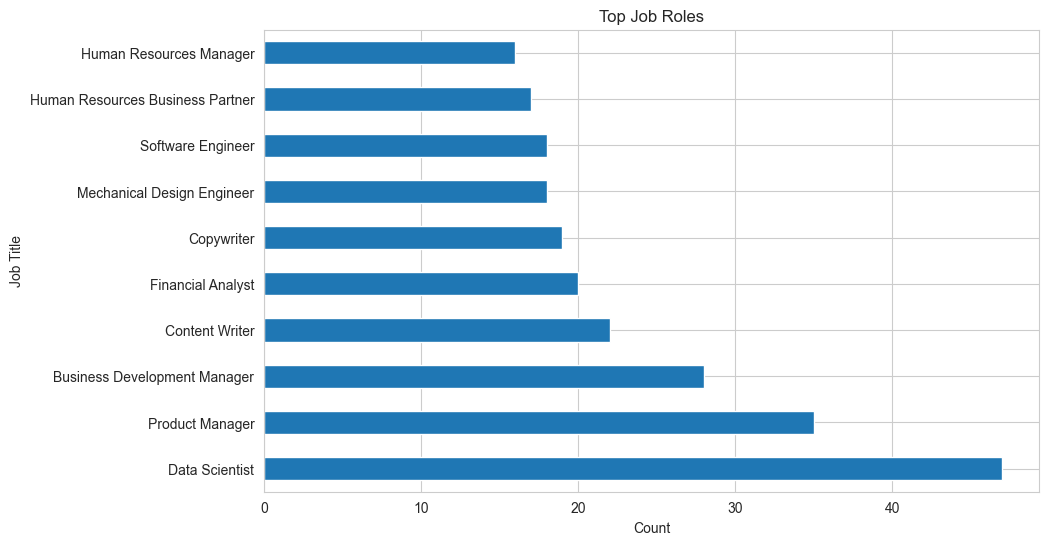

In [53]:
plt.figure(figsize=(10,6))

top_jobs = df["title"].value_counts().head(10)

top_jobs.plot(kind='barh')
plt.title("Top Job Roles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

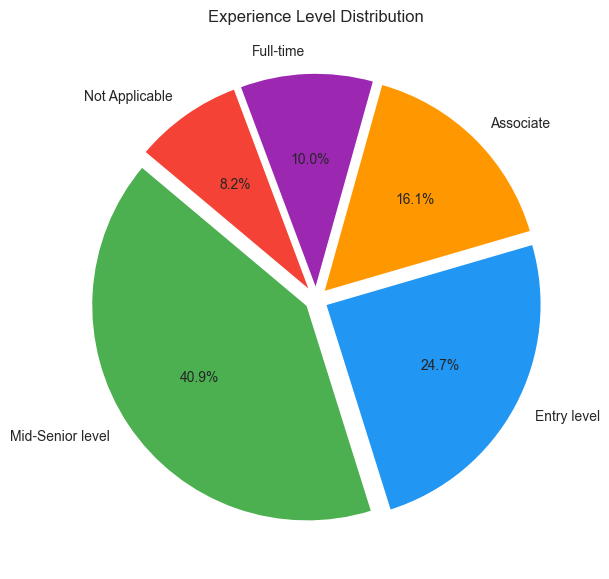

In [81]:
plt.figure(figsize=(7,7))

exp = df["experienceLevel"].value_counts().head(5)

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']

# Create slice effect
explode = [0.05]*len(exp)

plt.pie(exp, labels=exp.index, autopct='%1.1f%%',
        colors=colors, startangle=140,
        explode=explode)

plt.title("Experience Level Distribution")

plt.show()

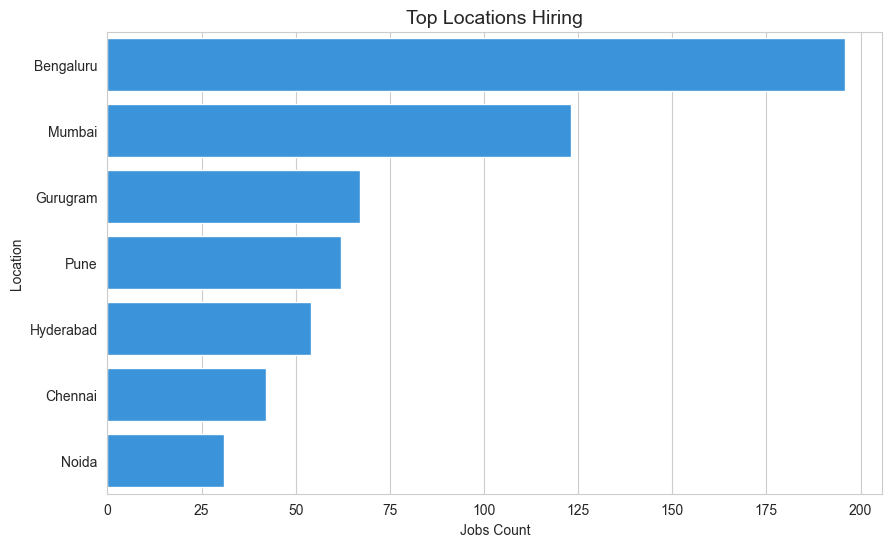

In [66]:
plt.figure(figsize=(10,6))

top_loc = df["city"].value_counts().head(7)

sns.barplot(x=top_loc.values, y=top_loc.index, color='#2196F3')

plt.title("Top Locations Hiring", fontsize=14)
plt.xlabel("Jobs Count")
plt.ylabel("Location")

plt.show()

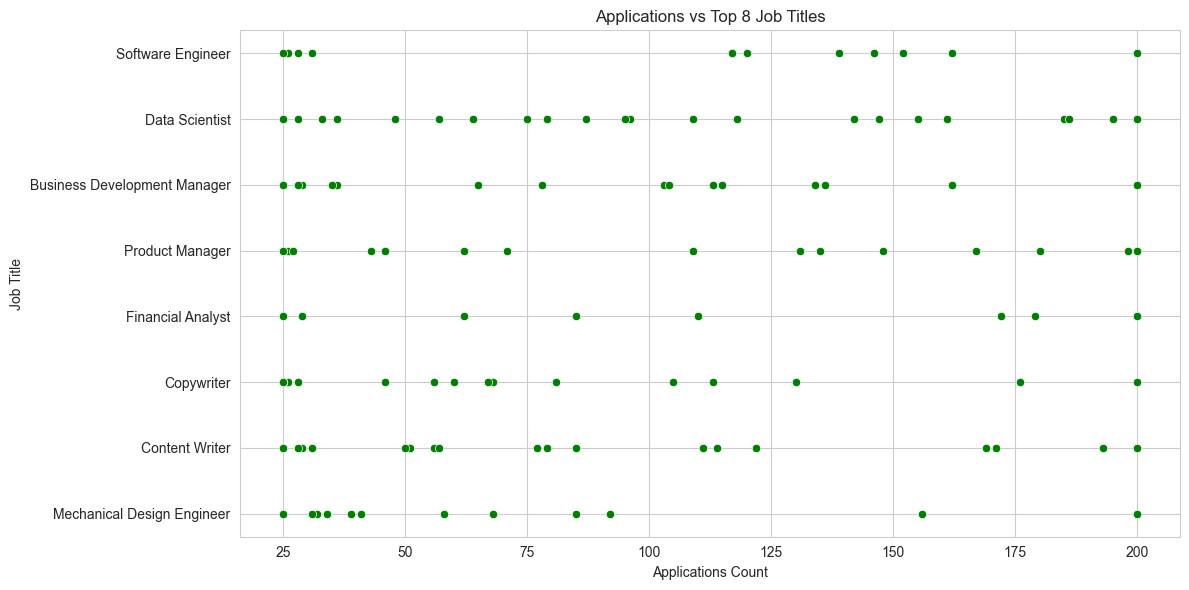

In [67]:
plt.figure(figsize=(12,6))

# Get top 8 job titles
top_titles = df["title"].value_counts().head(8).index

# Filter dataset
filtered_df = df[df["title"].isin(top_titles)]

sns.scatterplot(x=filtered_df["applicationsCount"], 
                y=filtered_df["title"],
                color='green')

plt.title("Applications vs Top 8 Job Titles")
plt.xlabel("Applications Count")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

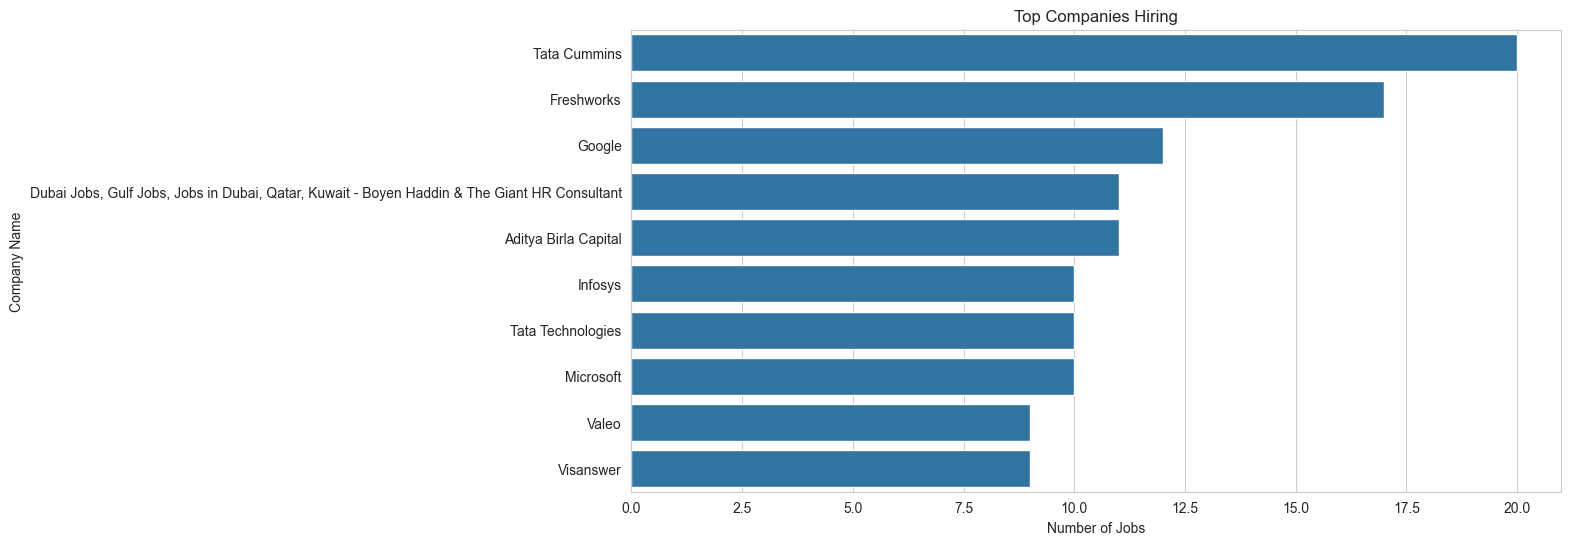

In [57]:
plt.figure(figsize=(12,6))

top_companies = df["companyName"].value_counts().head(10)

sns.barplot(x=top_companies.values, y=top_companies.index)

plt.title("Top Companies Hiring")
plt.xlabel("Number of Jobs")
plt.ylabel("Company Name")

plt.show()

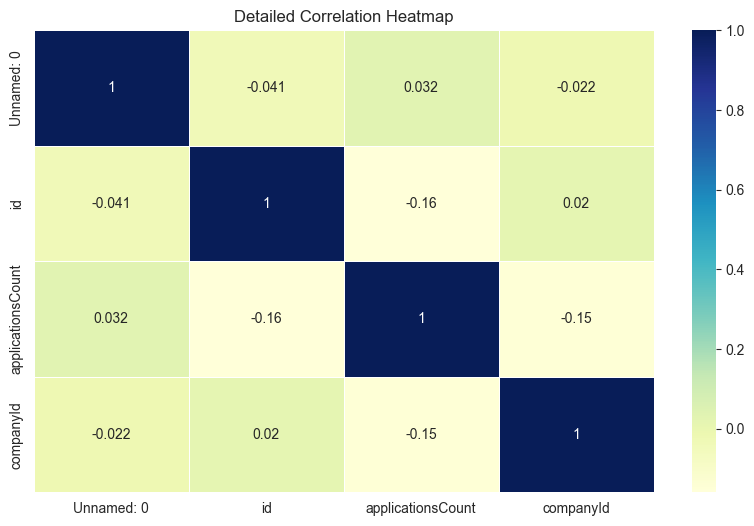

In [69]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap="YlGnBu", linewidths=0.5)

plt.title("Detailed Correlation Heatmap")
plt.show()

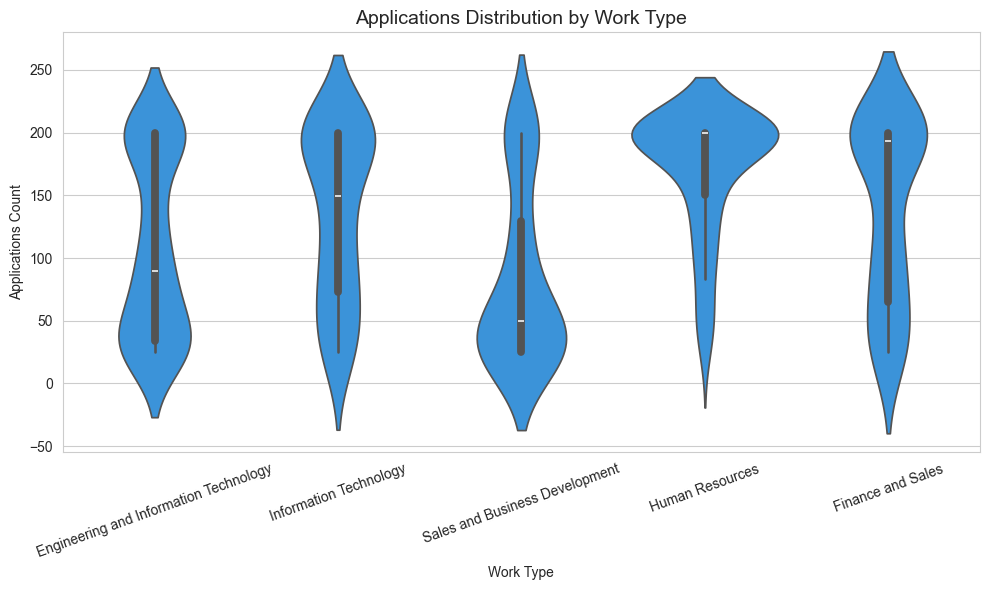

In [77]:
plt.figure(figsize=(10,6))

# Top 5 work types (avoid clutter)
top_work = df["workType"].value_counts().head(5).index
filtered_df = df[df["workType"].isin(top_work)]

sns.violinplot(x=filtered_df["workType"], 
               y=filtered_df["applicationsCount"],
               color='#2196F3')

plt.title("Applications Distribution by Work Type", fontsize=14)
plt.xlabel("Work Type")
plt.ylabel("Applications Count")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

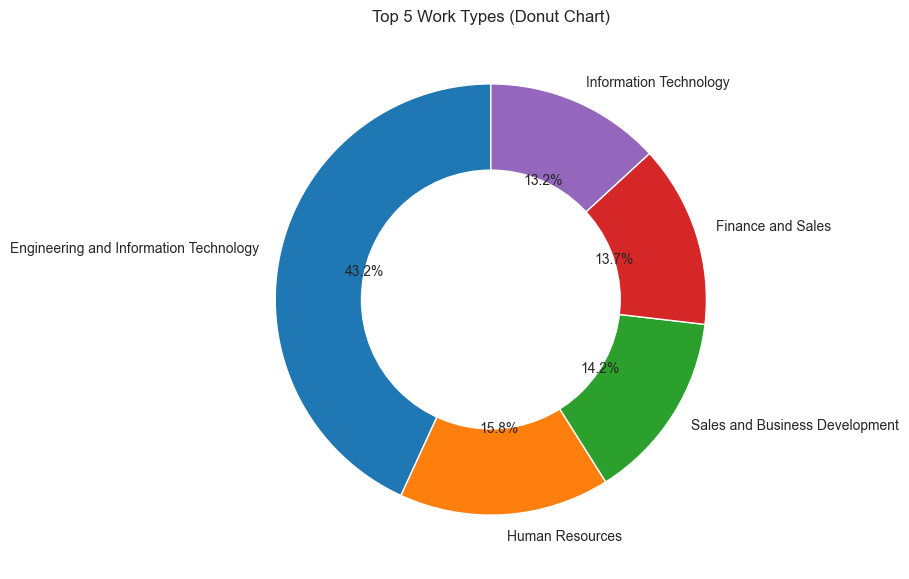

In [60]:
plt.figure(figsize=(7,7))

# Top 5 work types
top_work = df["workType"].value_counts().head(5)

# Create pie chart
plt.pie(top_work, labels=top_work.index, autopct='%1.1f%%', startangle=90)

# Create donut (circle in center)
centre_circle = plt.Circle((0,0), 0.6, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Top 5 Work Types (Donut Chart)")

plt.show()